# Assignment 3

This is an optional assignment for further exploration of transfer learning with deep networks. You will not be assessed but will receive feedback from the teaching staff.

Here, you are asked to practise the concept of transfer learning by fine-tuning a pre-trained network to classify a new dataset.

Follow instructions in the tutorial that you can find in:

https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

Report results with k-fold cross-validation.

In [22]:
# Load needed packages
from __future__ import print_function
from __future__ import division
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode
print("PyTorch Version: ",torch.__version__)
print("Torchvision Version: ",torchvision.__version__)

PyTorch Version:  2.3.1+cu118
Torchvision Version:  0.18.1+cu118


### Load dataset

#### Data augmentation and normalization for training

In [5]:
import os

print(os.getcwd())
print(os.listdir("."))          # should show 'data_2'
print(os.listdir("data_2"))     # should show ['train', 'val']
print(os.listdir("data_2/train"))  # should show ['ants', 'bees']

# removing hidden directories from the dataset
import shutil

shutil.rmtree("data_2/.ipynb_checkpoints", ignore_errors=True)
shutil.rmtree("data_2/train/.ipynb_checkpoints", ignore_errors=True)
shutil.rmtree("data_2/val/.ipynb_checkpoints", ignore_errors=True)

/home/jovyan/CV_IC
['.ipynb_checkpoints', 'Assignment 0v2 - Numpy intro.ipynb', 'cifar-10-python.tar.gz', 'Assignment 1 - Understanding a dataset.ipynb', 'Assignment 0v1 - Skimage intro.ipynb', 'Assignment 0v3 - Image manipulation.ipynb', 'README.md', 'Assignment 2 - Feature extraction and classification.ipynb', 'cifar-10-batches-py', 'Images', 'Assignment 3 - Transfer learning.ipynb', 'data', 'Original-ResNet-18-Architecture.png', 'core.367', 'core.690', 'data_2']
['train', 'val']
['ants', 'bees']


In [4]:
'''Your solution goes here'''
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'data_2'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.
device = "cuda" if torch.cuda.is_available() else "cpu"
#device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


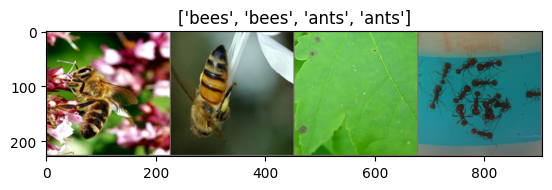

In [9]:
# Visualizing the dataset
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

### Load pretrained a network to fine-tune. 
You can use different networks for this purpose.

[resnet, alexnet, vgg, squeezenet, densenet, inception]


In [19]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

### Initialize the model

In [23]:
'''Your solution goes here'''
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5286 Acc: 0.7102
val Loss: 0.2417 Acc: 0.9085

Epoch 1/24
----------
train Loss: 0.5263 Acc: 0.7837
val Loss: 0.2323 Acc: 0.9281

Epoch 2/24
----------
train Loss: 0.6236 Acc: 0.7429
val Loss: 0.4756 Acc: 0.8301

Epoch 3/24
----------
train Loss: 0.4804 Acc: 0.8286
val Loss: 0.2422 Acc: 0.9150

Epoch 4/24
----------
train Loss: 0.5179 Acc: 0.7959
val Loss: 0.2343 Acc: 0.8954

Epoch 5/24
----------
train Loss: 0.5013 Acc: 0.7714
val Loss: 0.3424 Acc: 0.8627

Epoch 6/24
----------
train Loss: 0.3787 Acc: 0.8653
val Loss: 0.3142 Acc: 0.8758

Epoch 7/24
----------
train Loss: 0.3480 Acc: 0.8653
val Loss: 0.2114 Acc: 0.9281

Epoch 8/24
----------
train Loss: 0.2856 Acc: 0.8980
val Loss: 0.2169 Acc: 0.9216

Epoch 9/24
----------
train Loss: 0.2878 Acc: 0.8898
val Loss: 0.2083 Acc: 0.9281

Epoch 10/24
----------
train Loss: 0.3084 Acc: 0.8612
val Loss: 0.2184 Acc: 0.9085

Epoch 11/24
----------
train Loss: 0.2314 Acc: 0.9020
val Loss: 0.1970 Acc: 0.9346

Ep

### Build function to train your model

In [24]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [25]:
# Visualizing the model predictions
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

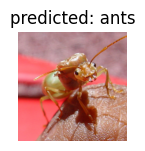

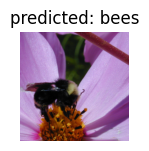

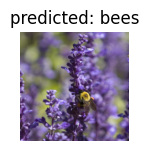

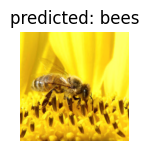

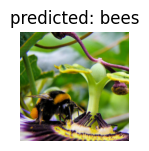

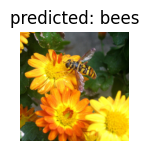

In [26]:
visualize_model(model_ft)

### Create an optimizer that only updates the desired parameters

In [27]:
'''Your solution goes here'''
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

### Run training

In [28]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5508 Acc: 0.7306
val Loss: 0.2194 Acc: 0.9346

Epoch 1/24
----------
train Loss: 0.5873 Acc: 0.7306
val Loss: 0.1560 Acc: 0.9412

Epoch 2/24
----------
train Loss: 0.3209 Acc: 0.8490
val Loss: 0.1810 Acc: 0.9346

Epoch 3/24
----------
train Loss: 0.5395 Acc: 0.7592
val Loss: 0.1661 Acc: 0.9346

Epoch 4/24
----------
train Loss: 0.4544 Acc: 0.8041
val Loss: 0.2340 Acc: 0.9085

Epoch 5/24
----------
train Loss: 0.3611 Acc: 0.8571
val Loss: 0.1975 Acc: 0.9346

Epoch 6/24
----------
train Loss: 0.5143 Acc: 0.7878
val Loss: 0.9407 Acc: 0.7059

Epoch 7/24
----------
train Loss: 0.6786 Acc: 0.7510
val Loss: 0.1956 Acc: 0.9346

Epoch 8/24
----------
train Loss: 0.3910 Acc: 0.8367
val Loss: 0.2691 Acc: 0.9020

Epoch 9/24
----------
train Loss: 0.3035 Acc: 0.8612
val Loss: 0.1880 Acc: 0.9412

Epoch 10/24
----------
train Loss: 0.3922 Acc: 0.8571
val Loss: 0.1882 Acc: 0.9346

Epoch 11/24
----------
train Loss: 0.3135 Acc: 0.8816
val Loss: 0.2028 Acc: 0.9477

Ep

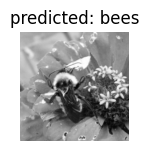

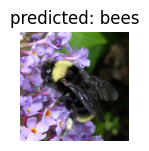

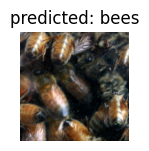

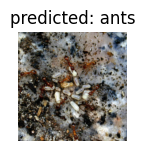

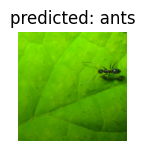

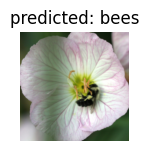

In [29]:
visualize_model(model_conv)

plt.ioff()
plt.show()

### Inference on custom images

In [30]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

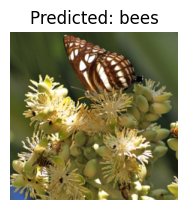

In [32]:
visualize_model_predictions(
    model_conv,
    img_path='data_2/val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()

--------------------------

## k-fold cross validation

Follow tutorial in https://medium.com/dataseries/k-fold-cross-validation-with-pytorch-and-sklearn-d094aa00105f

Pay attention to how different optimizers are used. Practise with both and see how the performance is affected.

In [ ]:
from sklearn.model_selection import KFold


In [ ]:
'''Your solution goes here'''